In [9]:
import numpy as np
from shapely.geometry import LineString
import trimesh
import matplotlib.pyplot as plt

In [10]:
mesh = trimesh.load_mesh('cylinder.stl')

In [11]:
z_min, z_max = mesh.bounds[0, 2], mesh.bounds[1, 2]
floors = 36
heights = np.linspace(0, z_max - z_min, floors + 1) # For some reason, the entire model shifts to be on the zero plane
floor_height = heights[1] - heights[0]
display(heights)

array([  0.        ,  13.41666709,  26.83333418,  40.25000127,
        53.66666836,  67.08333545,  80.50000254,  93.91666963,
       107.33333672, 120.75000381, 134.16667091, 147.583338  ,
       161.00000509, 174.41667218, 187.83333927, 201.25000636,
       214.66667345, 228.08334054, 241.50000763, 254.91667472,
       268.33334181, 281.7500089 , 295.16667599, 308.58334308,
       322.00001017, 335.41667726, 348.83334435, 362.25001144,
       375.66667853, 389.08334563, 402.50001272, 415.91667981,
       429.3333469 , 442.75001399, 456.16668108, 469.58334817,
       483.00001526])

In [12]:
sections = mesh.section_multiplane(
    plane_origin=mesh.bounds[0],
    plane_normal=[0, 0, 1],
    heights=heights[:-1]
)
display(sections)

[<trimesh.Path2D(vertices.shape=(80, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices.shape=(160, 2), len(entities)=2)>,
 <trimesh.Path2D(vertices

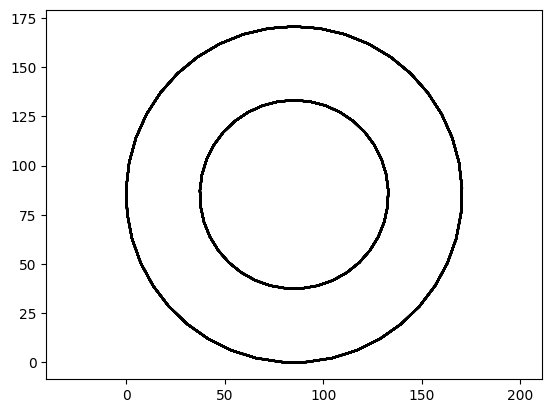

In [13]:
np.sum(sections).show()
extrusions = []
for i in range(len(sections)):
    floorplans = sections[i].extrude(floor_height)
    floorplans = floorplans if type(floorplans) is list else [floorplans]
    [floorplan.slide(heights[i]) for floorplan in floorplans]
    extrusions.extend(floorplans)
extrusions = trimesh.util.concatenate(extrusions)
extrusions.show()

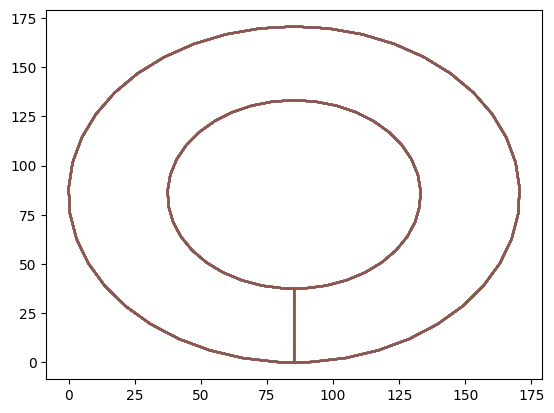

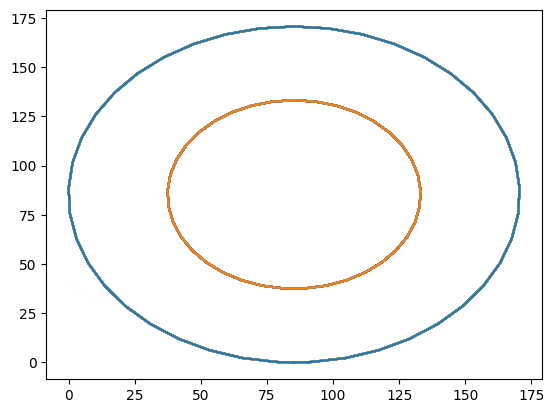

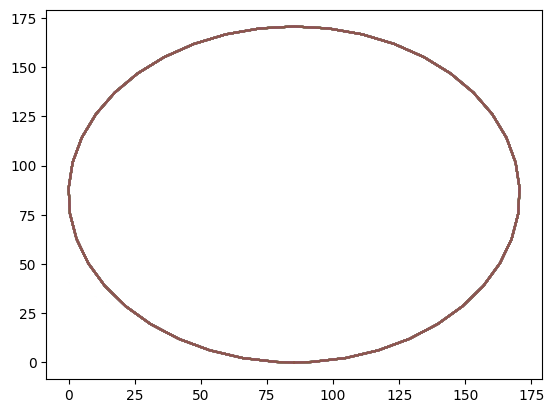

In [14]:
for section in sections:
    shape_floor = np.concat([polygon.exterior.xy for polygon in section.polygons_closed], axis=1)
    plt.plot(shape_floor[0], shape_floor[1])
plt.show()

for section in sections:
    [plt.plot(polygon.exterior.xy[0], polygon.exterior.xy[1]) for polygon in section.polygons_closed]
plt.show()

for section in sections:
    [plt.plot(polygon.exterior.xy[0], polygon.exterior.xy[1]) for polygon in section.polygons_full]
plt.show()